# 🗺️ Thuiszorg Route Algoritme
**Doel:** Optimale routes berekenen voor thuiszorgmedewerkers in Heerlen.

## Structuur
1. Installaties & imports
2. Testdata (medewerkers + cliënten)
3. Afstandsmatrix berekenen
4. OR-Tools VRP oplossen
5. Resultaat visualiseren
6. _(Later)_ Koppeling met dashboard via Flask API

## 1. Installaties & Imports

In [1]:
# Uncomment om te installeren indien nodig
%pip install ortools osmnx folium networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

print('Imports geslaagd')

Imports geslaagd


## 2. Testdata
Hier definiëren we medewerkers en cliënten als Python dictionaries.
Later wordt deze data vervangen door de data uit het dashboard.

In [3]:
# --- MEDEWERKERS ---
# Elk heeft een naam, startlocatie (x, y) en werktijden
# Later: echte GPS coördinaten van adressen in Heerlen
medewerkers = [
    {"id": 1, "naam": "Anna",  "locatie": (20, 80), "start": "08:00", "eind": "17:00"},
    {"id": 2, "naam": "Ben",   "locatie": (80, 20), "start": "08:00", "eind": "17:00"},
    {"id": 3, "naam": "Clara", "locatie": (50, 50), "start": "09:00", "eind": "17:00"},
]

# --- CLIËNTEN ---
# Elk heeft een naam, locatie (x, y) en zorgduur in minuten
# Later: echte GPS coördinaten van adressen in Heerlen
clienten = [
    {"id": 1,  "naam": "Piet",    "locatie": (30, 70), "duur": 60},
    {"id": 2,  "naam": "Marie",   "locatie": (45, 85), "duur": 45},
    {"id": 3,  "naam": "Henk",    "locatie": (60, 75), "duur": 30},
    {"id": 4,  "naam": "Truus",   "locatie": (25, 40), "duur": 60},
    {"id": 5,  "naam": "Jan",     "locatie": (70, 30), "duur": 45},
    {"id": 6,  "naam": "Lies",    "locatie": (85, 60), "duur": 30},
    {"id": 7,  "naam": "Koos",    "locatie": (15, 55), "duur": 60},
    {"id": 8,  "naam": "Els",     "locatie": (55, 25), "duur": 45},
    {"id": 9,  "naam": "Wim",     "locatie": (90, 45), "duur": 30},
    {"id": 10, "naam": "Griet",   "locatie": (40, 15), "duur": 60},
]

print(f'✓ {len(medewerkers)} medewerkers, {len(clienten)} cliënten geladen')

✓ 3 medewerkers, 10 cliënten geladen


## 3. Afstandsmatrix
OR-Tools heeft een afstandsmatrix nodig: de afstand tussen elk punt en elk ander punt.

Nu gebruiken we Euclidische (luchtlijn) afstand.
**Later:** vervangen door echte rijafstanden via OSMnx op de wegenkaart van Heerlen.

In [4]:
def euclidische_afstand(p1, p2):
    """Berekent de rechte-lijn afstand tussen twee punten."""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def maak_afstandsmatrix(medewerkers, clienten):
    """
    Bouwt een NxN afstandsmatrix.
    Index 0 t/m (n_mw-1)      = depots (startlocaties medewerkers)
    Index n_mw t/m einde      = cliënten
    """
    alle_locaties = [m["locatie"] for m in medewerkers] + [c["locatie"] for c in clienten]
    n = len(alle_locaties)
    matrix = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            if i != j:
                # Vermenigvuldig met 100 en rond af → OR-Tools werkt met integers
                matrix[i][j] = int(euclidische_afstand(alle_locaties[i], alle_locaties[j]) * 100)
    
    return matrix, alle_locaties

afstand_matrix, alle_locaties = maak_afstandsmatrix(medewerkers, clienten)

print(f'✓ Afstandsmatrix aangemaakt: {len(alle_locaties)}x{len(alle_locaties)} punten')
print(f'  Eerste {len(medewerkers)} indices = medewerker depots')
print(f'  Overige {len(clienten)} indices = cliënten')

✓ Afstandsmatrix aangemaakt: 13x13 punten
  Eerste 3 indices = medewerker depots
  Overige 10 indices = cliënten


## 4. OR-Tools VRP Oplossen
VRP = Vehicle Routing Problem
- Elke medewerker = een 'voertuig'
- Elke cliënt = een 'stop' die bezocht moet worden
- Doel: minimaliseer de totale reistijd

In [5]:
def los_vrp_op(afstand_matrix, n_medewerkers, n_clienten, max_tijd=30):
    """
    Lost het Vehicle Routing Problem op met OR-Tools.
    
    Parameters:
        afstand_matrix  : NxN matrix met afstanden
        n_medewerkers   : aantal medewerkers (= aantal voertuigen)
        n_clienten      : aantal cliënten (= aantal stops)
        max_tijd        : maximale rekentijd in seconden
    
    Returns:
        routes : dict {medewerker_index: [lijst van cliënt indices]}
        status : 'OPTIMAAL', 'GOED GENOEG', of 'GEEN OPLOSSING'
    """
    n_nodes = n_medewerkers + n_clienten
    
    # Elke medewerker heeft zijn eigen depot (startpunt = zijn locatie)
    depots = list(range(n_medewerkers))
    
    # OR-Tools manager aanmaken
    manager = pywrapcp.RoutingIndexManager(
        n_nodes,        # totaal aantal nodes
        n_medewerkers,  # aantal voertuigen
        depots,         # start depots
        depots          # eind depots (zelfde = medewerker keert terug)
    )
    
    routing = pywrapcp.RoutingModel(manager)
    
    # Afstandsfunctie registreren
    def afstand_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return afstand_matrix[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(afstand_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    # Dimensie toevoegen voor totale reistijd per medewerker
    routing.AddDimension(
        transit_callback_index,
        0,       # geen wachttijd
        100000,  # max reistijd per medewerker
        True,    # start op 0
        'Afstand'
    )
    
    # Balanceer de routes: probeer gelijke werkdruk
    afstand_dimensie = routing.GetDimensionOrDie('Afstand')
    afstand_dimensie.SetGlobalSpanCostCoefficient(100)
    
    # Zoekstrategie instellen
    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_params.time_limit.seconds = max_tijd
    
    # Oplossen
    oplossing = routing.SolveWithParameters(search_params)
    
    if not oplossing:
        return {}, 'GEEN OPLOSSING'
    
    # Resultaat uitlezen
    routes = {}
    for mw_idx in range(n_medewerkers):
        index = routing.Start(mw_idx)
        route = []
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            # Alleen cliënten toevoegen (niet het depot zelf)
            if node >= n_medewerkers:
                client_idx = node - n_medewerkers
                route.append(client_idx)
            index = oplossing.Value(routing.NextVar(index))
        routes[mw_idx] = route
    
    status_code = routing.status()
    if status_code == 1:
        status = 'OPTIMAAL'
    elif status_code == 2:
        status = 'GOED GENOEG'
    else:
        status = f'STATUS CODE {status_code}'
    
    return routes, status


# --- Uitvoeren ---
print('⏳ OR-Tools bezig met optimaliseren...')
routes, status = los_vrp_op(
    afstand_matrix,
    n_medewerkers=len(medewerkers),
    n_clienten=len(clienten),
    max_tijd=10  # 10 seconden rekentijd
)

print(f'\n✓ Resultaat: {status}')
print('\n--- Routes per medewerker ---')
for mw_idx, route in routes.items():
    mw = medewerkers[mw_idx]
    stops = [clienten[i]['naam'] for i in route]
    totaal = sum(
        euclidische_afstand(clienten[route[i]]['locatie'], clienten[route[i+1]]['locatie'])
        for i in range(len(route)-1)
    ) if len(route) > 1 else 0
    print(f"  {mw['naam']:8s} → {' → '.join(stops) if stops else '(geen stops)'} | afstand: {totaal:.1f}")

⏳ OR-Tools bezig met optimaliseren...

✓ Resultaat: OPTIMAAL

--- Routes per medewerker ---
  Anna     → Marie → Henk → Piet | afstand: 48.4
  Ben      → Els → Jan → Lies → Wim | afstand: 65.2
  Clara    → Koos → Truus → Griet | afstand: 47.2


## 5. Visualisatie
Toont de routes op een simpel 2D grid.
**Later:** vervangen door echte Leaflet kaart van Heerlen in het dashboard.

C:\Users\noudr\AppData\Local\Temp\ipykernel_31524\2624038547.py:61: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\noudr\Documents\Zuyd\ZM002 Artificial intelligence\CARAI-Artificial-Intelligence-group-2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


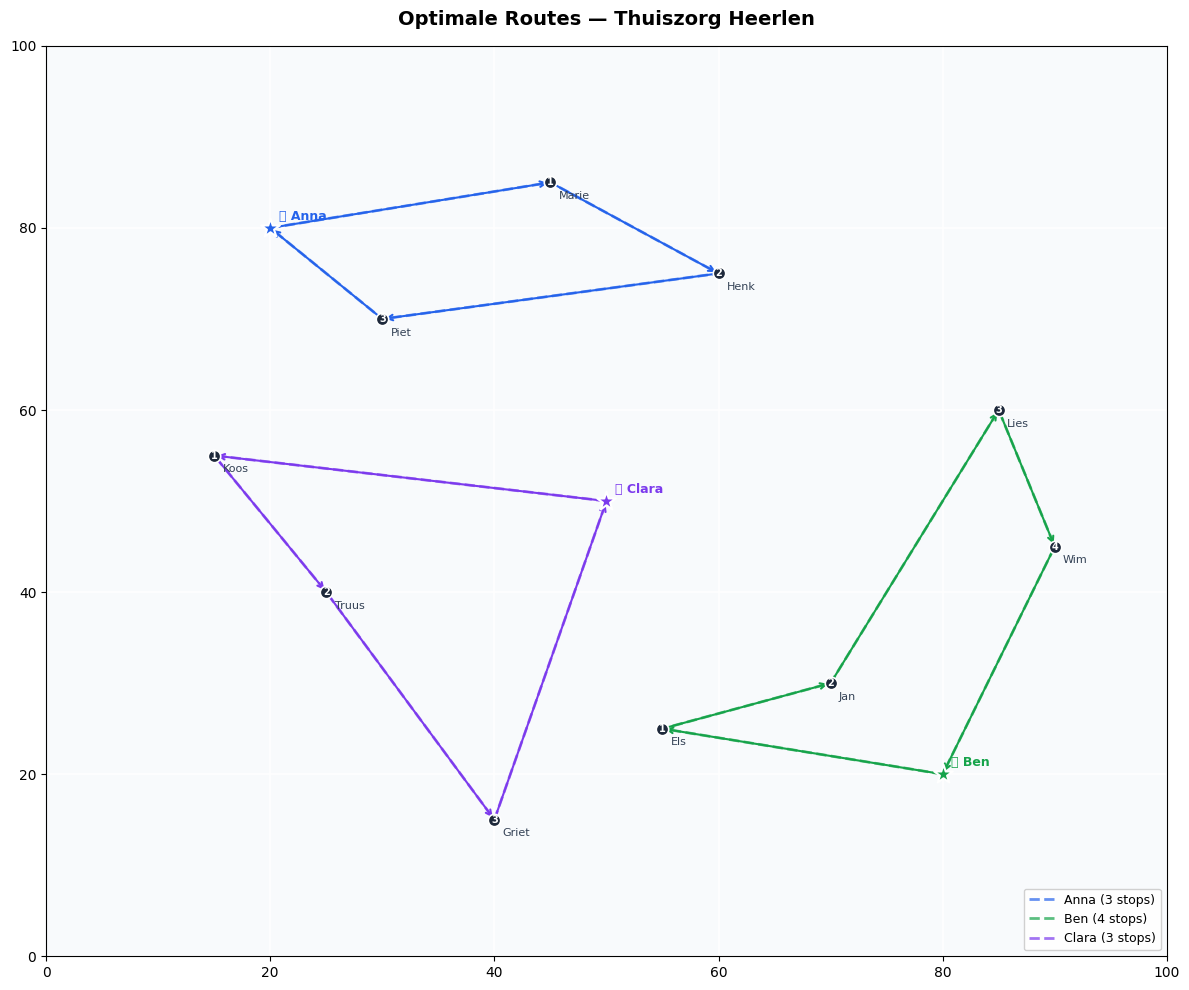

In [6]:
def visualiseer_routes(medewerkers, clienten, routes):
    """Tekent alle routes op een 2D grid met kleuren per medewerker."""
    
    kleuren = ['#2563eb', '#16a34a', '#7c3aed', '#ea580c', '#0891b2', '#be185d']
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.set_facecolor('#f8fafc')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, color='white', linewidth=1.5, alpha=0.8)
    ax.set_title('Optimale Routes — Thuiszorg Heerlen', fontsize=14, fontweight='bold', pad=15)
    
    # Teken routes per medewerker
    for mw_idx, route in routes.items():
        if not route:
            continue
        
        mw = medewerkers[mw_idx]
        kleur = kleuren[mw_idx % len(kleuren)]
        
        # Bouw de volledige route: depot → cliënten → depot
        alle_punten = [mw['locatie']] + [clienten[i]['locatie'] for i in route] + [mw['locatie']]
        xs = [p[0] for p in alle_punten]
        ys = [p[1] for p in alle_punten]
        
        # Teken lijn
        ax.plot(xs, ys, color=kleur, linewidth=2, alpha=0.7, 
                linestyle='--', label=f"{mw['naam']} ({len(route)} stops)")
        
        # Teken pijlen voor richting
        for i in range(len(xs)-1):
            dx = xs[i+1] - xs[i]
            dy = ys[i+1] - ys[i]
            ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                        arrowprops=dict(arrowstyle='->', color=kleur, lw=1.5))
        
        # Teken medewerker depot (ster)
        ax.scatter(*mw['locatie'], color=kleur, s=200, zorder=5, marker='*', 
                   edgecolors='white', linewidth=1.5)
        ax.annotate(f"🏠 {mw['naam']}", mw['locatie'], 
                    xytext=(6, 6), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=kleur)
        
        # Teken volgorde nummers op de stops
        for stap, cl_idx in enumerate(route):
            cl = clienten[cl_idx]
            ax.annotate(str(stap+1), cl['locatie'],
                        xytext=(0, 0), textcoords='offset points',
                        fontsize=7, color='white', fontweight='bold',
                        ha='center', va='center', zorder=7)
    
    # Teken alle cliënten
    for cl in clienten:
        ax.scatter(*cl['locatie'], color='#1e293b', s=80, zorder=4, 
                   edgecolors='white', linewidth=1.2)
        ax.annotate(cl['naam'], cl['locatie'],
                    xytext=(6, -12), textcoords='offset points',
                    fontsize=8, color='#334155')
    
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()


visualiseer_routes(medewerkers, clienten, routes)

## 6. Samenvatting
Statistieken van de gevonden oplossing.

In [7]:
print('=' * 50)
print('PLANNING SAMENVATTING')
print('=' * 50)
print(f'Status        : {status}')
print(f'Medewerkers   : {len(medewerkers)}')
print(f'Cliënten      : {len(clienten)}')
print()

totaal_afstand = 0
for mw_idx, route in routes.items():
    mw = medewerkers[mw_idx]
    stops = [clienten[i]['naam'] for i in route]
    zorg_minuten = sum(clienten[i]['duur'] for i in route)
    
    # Bereken reisafstand
    punten = [mw['locatie']] + [clienten[i]['locatie'] for i in route] + [mw['locatie']]
    reis = sum(euclidische_afstand(punten[i], punten[i+1]) for i in range(len(punten)-1))
    totaal_afstand += reis
    
    print(f"{mw['naam']}:")
    print(f"  Stops        : {len(route)} cliënten")
    print(f"  Zorg tijd    : {zorg_minuten} minuten")
    print(f"  Reisafstand  : {reis:.1f} eenheden")
    print(f"  Volgorde     : {' → '.join(stops) if stops else '(geen stops)'}")
    print()

print(f'Totale reisafstand: {totaal_afstand:.1f} eenheden')
print()
print('--- Volgende stap ---')
print('Vervang testdata door echte adressen uit het dashboard')
print('Vervang euclidische afstand door OSMnx rijafstanden op de wegenkaart van Heerlen')

PLANNING SAMENVATTING
Status        : OPTIMAAL
Medewerkers   : 3
Cliënten      : 10

Anna:
  Stops        : 3 cliënten
  Zorg tijd    : 135 minuten
  Reisafstand  : 88.1 eenheden
  Volgorde     : Marie → Henk → Piet

Ben:
  Stops        : 4 cliënten
  Zorg tijd    : 150 minuten
  Reisafstand  : 117.6 eenheden
  Volgorde     : Els → Jan → Lies → Wim

Clara:
  Stops        : 3 cliënten
  Zorg tijd    : 180 minuten
  Reisafstand  : 118.9 eenheden
  Volgorde     : Koos → Truus → Griet

Totale reisafstand: 324.6 eenheden

--- Volgende stap ---
Vervang testdata door echte adressen uit het dashboard
Vervang euclidische afstand door OSMnx rijafstanden op de wegenkaart van Heerlen


---
## 🔜 Volgende stappen

| Stap | Wat | Status |
|------|-----|--------|
| 1 | Testdata + OR-Tools VRP | ✅ Klaar |
| 2 | OSMnx: echte wegenkaart Heerlen laden | 🔜 Volgende |
| 3 | Echte rijafstanden i.p.v. luchtlijn | 🔜 |
| 4 | Flask API: koppeling met dashboard | 🔜 |
| 5 | Leaflet kaart in dashboard | 🔜 |
| 6 | Data uit dashboard → algoritme → kaart | 🔜 |